# Exercise 1 

In this exercise, we will work with the `sp500_historical.csv` data file. This file contains historical MasterCard stock price information from Nov-2019 to Nov-2024. The goal is to build `LSTM` models, using `TensorFlow`, to forecast `Close` prices.

### Exercise 1(a) (2 points)

Load the below libraries.

```
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import tensorflow as tf
```

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import tensorflow as tf

### Exercise 1(b) (4 points)

Read the `sp500_historical.csv` data file and create a data frame called `df`. Make sure `Date` is a in the appropriate `datetime` format. Update the columns names to: `['Date', 'Close', 'Open', 'High', 'Low']`.

In [2]:
df = pd.read_csv('sp500_historical.csv')
df.head()

,Date,Close/Last,Open,High,Low
0,11/06/2024,5929.04,5864.89,5936.14,5864.89
1,11/05/2024,5782.76,5722.43,5783.44,5722.10
2,11/04/2024,5712.69,5725.15,5741.43,5696.51
3,11/01/2024,5728.80,5723.22,5772.52,5723.22
4,10/31/2024,5705.45,5775.34,5775.34,5702.86


In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,Date,Close/Last,Open,High,Low
0,2024-11-06,5929.04,5864.89,5936.14,5864.89
1,2024-11-05,5782.76,5722.43,5783.44,5722.10
2,2024-11-04,5712.69,5725.15,5741.43,5696.51
3,2024-11-01,5728.80,5723.22,5772.52,5723.22
4,2024-10-31,5705.45,5775.34,5775.34,5702.86


### Exercise 1(c) (3 points)

Create a time-series plot of `Close`. 

In [6]:
df = df.rename(columns={'Close/Last': 'Close'})
df.head()

,Date,Close,Open,High,Low
0,2024-11-06,5929.04,5864.89,5936.14,5864.89
1,2024-11-05,5782.76,5722.43,5783.44,5722.10
2,2024-11-04,5712.69,5725.15,5741.43,5696.51
3,2024-11-01,5728.80,5723.22,5772.52,5723.22
4,2024-10-31,5705.45,5775.34,5775.34,5702.86


### Exercise 1(d) (5 points)

Split the data into `train` (`Close` observations from 01-01-2021 up to 06-30-2024) and `test` (`Close` observations starting from 07-01-2024). Visualize both data sets.

In [7]:
train = df[df['Date'] <= pd.to_datetime('6-30-2024')]['Close'].values.reshape(-1,1)
test = df[df['Date'] > pd.to_datetime('6-30-2024')]['Close'].values.reshape(-1,1)

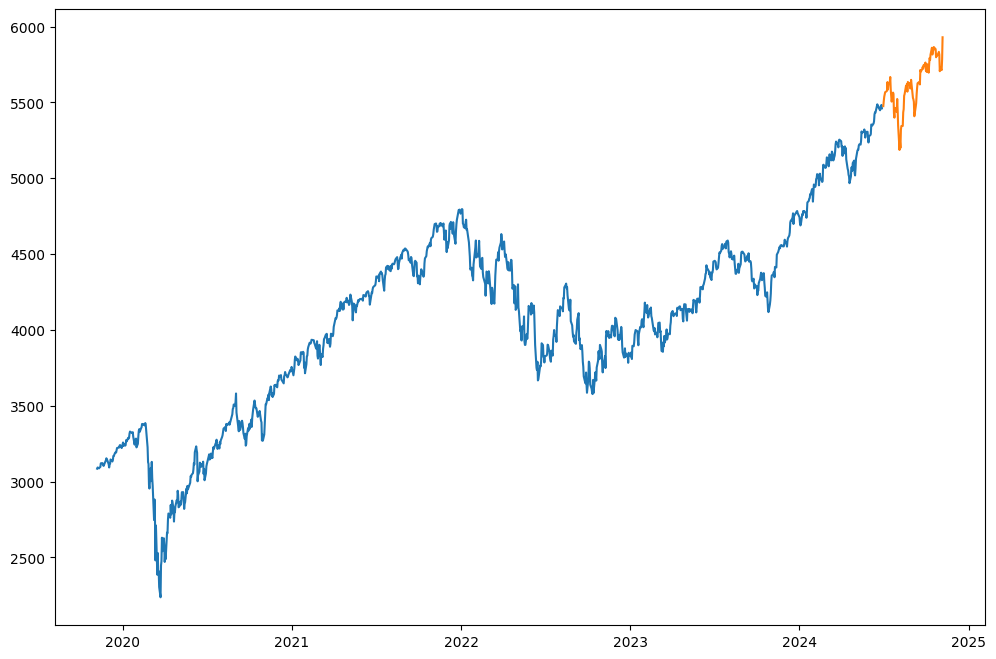

In [9]:
fig = plt.figure(figsize=(12,8))

plt.plot('Date', 'Close', data = df[df['Date']<= pd.to_datetime('6-30-2024')], label='training')
plt.plot('Date', 'Close', data = df[df['Date'] > pd.to_datetime('6-30-2024')], label='testing')

### Exercise 1(e) (3 points)

Standardize the data using the `StandardScaler` from `sklearn.preprocessing`.

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(train)
train_scaled = scaler.transform(train)
test_scaled = scaler.transform(test)

### Exercise 1(f) (8 points)

Create a function called `convert_time_series` that takes two arguments: `sequence` (the time series) and `n_steps` (time window). Notice that this function converts the time-series task into a regression task. Convert the `train` and `test` time-series into inputs and outputs using the `convert_time_series` and `n_steps=50`. 

In [11]:
def convert_ts(sequence, n_steps):
    X, y = [],[]
    for i in range(len(sequence)):
        end_ix = i + n_steps
        if end_ix > len(sequence)-1:
            break
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)
        
n_steps = 50
X_train, y_train = convert_ts(train_scaled, n_steps)
X_test, y_test = convert_ts(test_scaled, n_steps)

### Exercise 1(g) (10 points)

Build a `LSTM` model as follows:

- 25 units and `activation=tanh`. 
- `optimizer="RMSprop"` and `loss='mae'`.

Then, 

- Train the model over 5 time-series folds (use `TimeSeriesSplit(n_splits=5, test_size=91)` from `sklearn.model_selection`). 
- Use `epochs=20` and `batch_size=32`.
- Report the average mean absolute error. 
- Re-train the model using the entire train data set and predict on the test data set.
- Visualize the model predictions with true values.

In [12]:
from sklearn.model_selection import TimeSeriesSplit

md1 = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(25, activation='tanh', input_shape=(100,1)),
    tf.keras.layers.Dense(1)                        
])

md1.compile(optimizer='RMSprop', loss='mae')

scores = []
tscv = TimeSeriesSplit(n_splits=5, test_size=91)

for i,(train_idx, test_idx) in enumerate(tscv.split(X_train)):

    X_train_cv, y_train_cv = X_train[train_idx], y_train[train_idx]
    X_test_cv, y_test_cv = X_train[test_idx], y_train[test_idx]
    
    md1.fit(X_train_cv, y_train_cv, epochs = 20, batch_size=32, validation_data=(X_test_cv,y_test_cv), verbose=0)
    score = md1.evaluate(X_test_cv, y_test_cv, verbose=0, batch_size=32)
    scores.append(score)
    print(f'Fold {i+1} score: {score}')
    
print('mean score:', np.mean(scores))

c:\Users\gmgma\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Fold 1 score: 0.03727136552333832
Fold 2 score: 0.04416033998131752
Fold 3 score: 0.06359341740608215
Fold 4 score: 0.1117783859372139
Fold 5 score: 0.09750152379274368
mean score: 0.07086100652813912


In [13]:
md1.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)

test_loss = md1.evaluate(X_test, y_test, batch_size=32, verbose=0)

print('test loss:', test_loss)

test loss: 0.07408972829580307


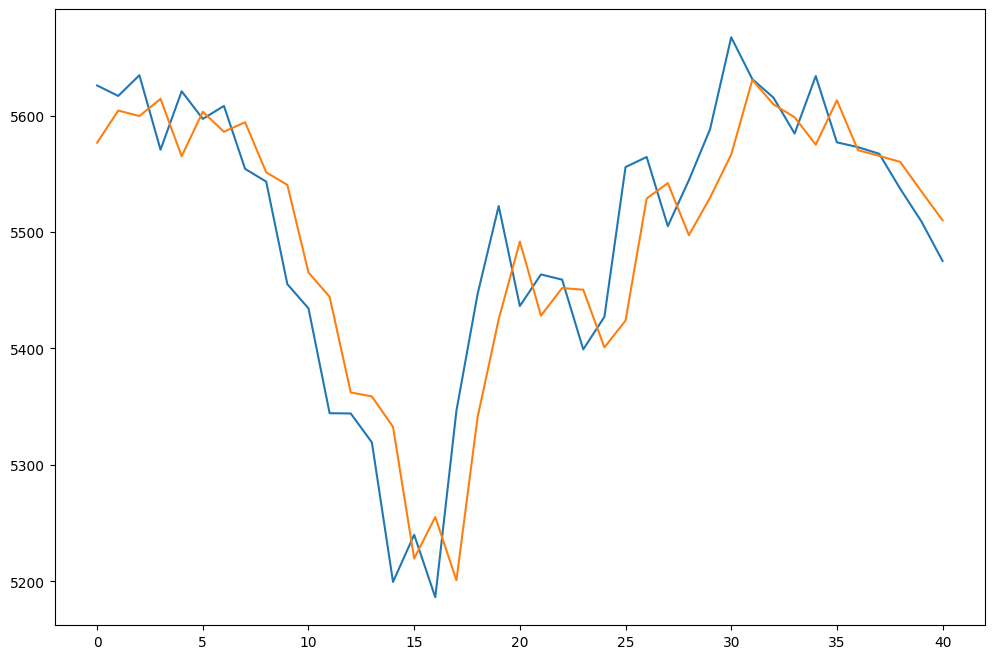

In [14]:
y_pred = md1.predict(X_test, verbose=0, batch_size=32)

y_pred_raw = scaler.inverse_transform(y_pred)
y_test_raw = scaler.inverse_transform(y_test)

plt.figure(figsize=(12,8))

plt.plot(y_test_raw, label='True Price')
plt.plot(y_pred_raw, label='predicted price')

### Exercise 1(h) (10 points)

Build a `LSTM` model as follows:

- 50 units and `activation=tanh`. 
- `optimizer="RMSprop"` and `loss='mae'`.

Then, 

- Train the model over 5 time-series folds (use `TimeSeriesSplit(n_splits=5, test_size=91)` from `sklearn.model_selection`). 
- Use `epochs=20` and `batch_size=32`.
- Report the average mean absolute error. 
- Re-train the model using the entire train data set and predict on the test data set.
- Visualize the model predictions with true values.

In [15]:
md2 = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(50, activation='tanh', input_shape=(100,1)),
    tf.keras.layers.Dense(1)                        
])

md2.compile(optimizer='RMSprop', loss='mae')

scores = []
tscv = TimeSeriesSplit(n_splits=5, test_size=91)

for i,(train_idx, test_idx) in enumerate(tscv.split(X_train)):

    X_train_cv, y_train_cv = X_train[train_idx], y_train[train_idx]
    X_test_cv, y_test_cv = X_train[test_idx], y_train[test_idx]
    
    md2.fit(X_train_cv, y_train_cv, epochs = 20, batch_size=32, validation_data=(X_test_cv,y_test_cv), verbose=0)
    score = md2.evaluate(X_test_cv, y_test_cv, verbose=0, batch_size=32)
    scores.append(score)
    print(f'Fold {i+1} score: {score}')
    
print('mean score:', np.mean(scores))

c:\Users\gmgma\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Fold 1 score: 0.039352402091026306
Fold 2 score: 0.04953416809439659
Fold 3 score: 0.06752625107765198
Fold 4 score: 0.07156747579574585
Fold 5 score: 0.06670559197664261
mean score: 0.058937177807092664


In [16]:
md2.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)

test_loss = md2.evaluate(X_test, y_test, batch_size=32, verbose=0)

print('test loss:', test_loss)

test loss: 0.07683055847883224


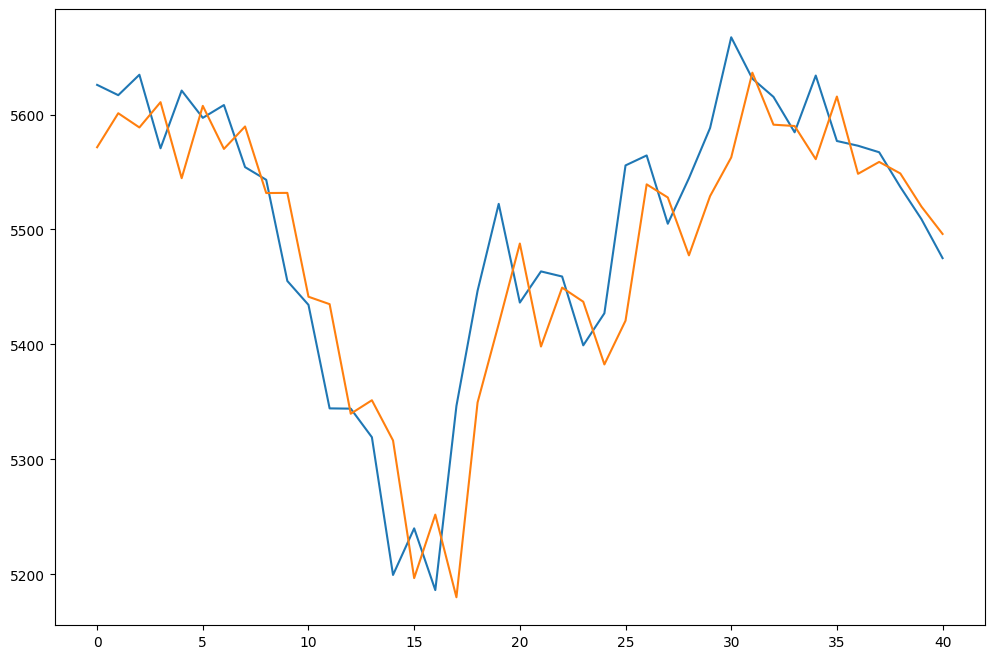

In [17]:
y_pred = md2.predict(X_test, verbose=0, batch_size=32)

y_pred_raw = scaler.inverse_transform(y_pred)
y_test_raw = scaler.inverse_transform(y_test)

plt.figure(figsize=(12,8))

plt.plot(y_test_raw, label='True Price')
plt.plot(y_pred_raw, label='predicted price')

### Exercise 1(i) (10 points)

Build a `LSTM` model as follows:

- 75 units and `activation=tanh`. 
- `optimizer="RMSprop"` and `loss='mae'`.

Then, 

- Train the model over 5 time-series folds (use `TimeSeriesSplit(n_splits=5, test_size=91)` from `sklearn.model_selection`). 
- Use `epochs=20` and `batch_size=32`.
- Report the average mean absolute error. 
- Re-train the model using the entire train data set and predict on the test data set.
- Visualize the model predictions with true values.

In [18]:
md3 = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(75, activation='tanh', input_shape=(100,1)),
    tf.keras.layers.Dense(1)                        
])

md3.compile(optimizer='RMSprop', loss='mae')

scores = []
tscv = TimeSeriesSplit(n_splits=5, test_size=91)

for i,(train_idx, test_idx) in enumerate(tscv.split(X_train)):

    X_train_cv, y_train_cv = X_train[train_idx], y_train[train_idx]
    X_test_cv, y_test_cv = X_train[test_idx], y_train[test_idx]
    
    md3.fit(X_train_cv, y_train_cv, epochs = 20, batch_size=32, validation_data=(X_test_cv,y_test_cv), verbose=0)
    score = md3.evaluate(X_test_cv, y_test_cv, verbose=0, batch_size=32)
    scores.append(score)
    print(f'Fold {i+1} score: {score}')
    
print('mean score:', np.mean(scores))

c:\Users\gmgma\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Fold 1 score: 0.038607157766819
Fold 2 score: 0.04065737500786781
Fold 3 score: 0.09759317338466644
Fold 4 score: 0.0727333128452301
Fold 5 score: 0.11912292242050171
mean score: 0.07374278828501701


In [19]:
md3.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)

test_loss = md3.evaluate(X_test, y_test, batch_size=32, verbose=0)

print('test loss:', test_loss)

test loss: 0.07520454376935959


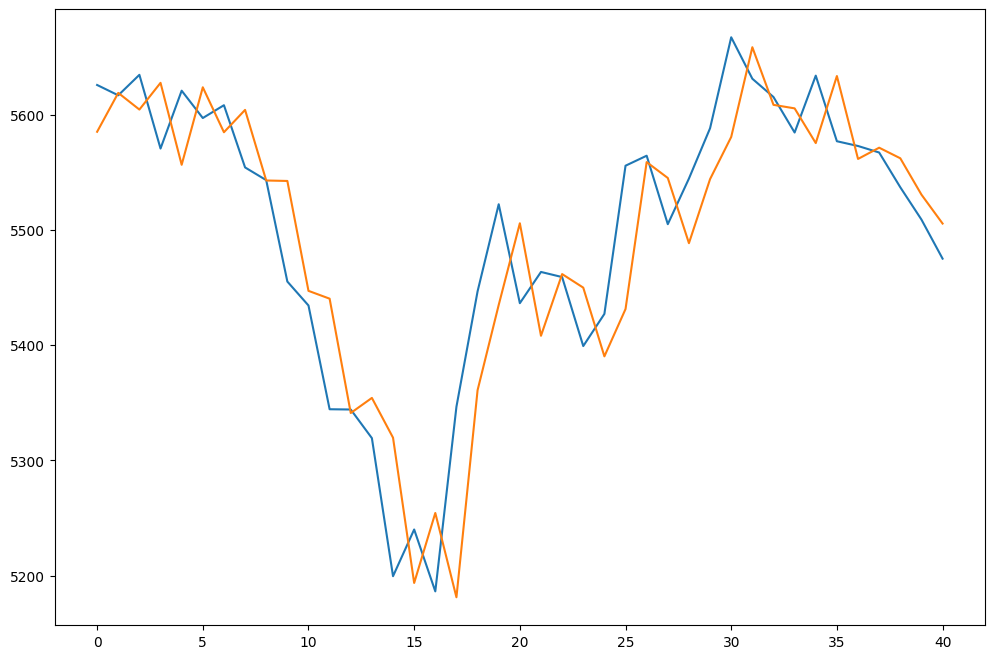

In [20]:
y_pred = md3.predict(X_test, verbose=0, batch_size=32)

y_pred_raw = scaler.inverse_transform(y_pred)
y_test_raw = scaler.inverse_transform(y_test)

plt.figure(figsize=(12,8))

plt.plot(y_test_raw, label='True Price')
plt.plot(y_pred_raw, label='predicted price')

### Exercise 1(j) (3 points)

Using the results from parts 1(g) to 1(i), what model would you use to predict the `Close` price of S&P500? Be specific.

Based on my results i would choose model 1 because it has the lowest mae